In [1]:
# Librerias
import os
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm   # barras de progreso
import urllib.request
import zipfile
from IPython.display import Audio, display

In [2]:
# --- Parámetros de audio ---
SAMPLE_RATE  = 16000   # Hz estándar del dataset
DURATION     = 1.0     # segundos
N_MFCC       = 40      # coeficientes MFCC
HOP_LENGTH   = 512
N_FFT        = 2048

# --- Parámetros de entrenamiento ---
BATCH_SIZE    = 64
EPOCHS        = 30
LEARNING_RATE = 0.001

# --- Clases a clasificar ---
COMMANDS = ['yes', 'no', 'up', 'down', 'left', 'right', 'stop', 'go']

# --- Archivos de salida en formato PATH
DATA_DIR    = 'Clases/Clase6/speech_commands_data'
MODEL_PATH  = 'Clases/Clase6/speech_lstm_model.keras'
LABELS_PATH = 'Clases/Clase6/label_classes.npy'

print('Configuración lista')

Configuración lista


In [ ]:
#Descarga del conjunto de datos

def download_dataset(data_dir=DATA_DIR):
    """Descarga y extrae el Mini Speech Commands dataset."""
    os.makedirs(data_dir, exist_ok=True)

    url      = 'http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip'
    zip_path = os.path.join(data_dir, 'mini_speech_commands.zip')
    extract  = os.path.join(data_dir, 'mini_speech_commands')

    if not os.path.exists(zip_path):
        print('Descargando dataset')
        urllib.request.urlretrieve(url, zip_path)
        print('Descarga completa')
    else:
        print('ZIP ya existe, omitiendo descarga')

    if not os.path.exists(extract):
        print('Extrayendo archivos')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(data_dir)
        print('Extracción completa')
    else:
        print('Dataset ya extraído')

    # Mostrar estructura
    folders = [f for f in os.listdir(extract) if os.path.isdir(os.path.join(extract, f))]
    print(f'\n Carpetas disponibles: {sorted(folders)}')
    return extract

data_dir = download_dataset()

Descargando dataset (~65 MB)...
Descarga completa
Extrayendo archivos...
Extracción completa

 Carpetas disponibles: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']


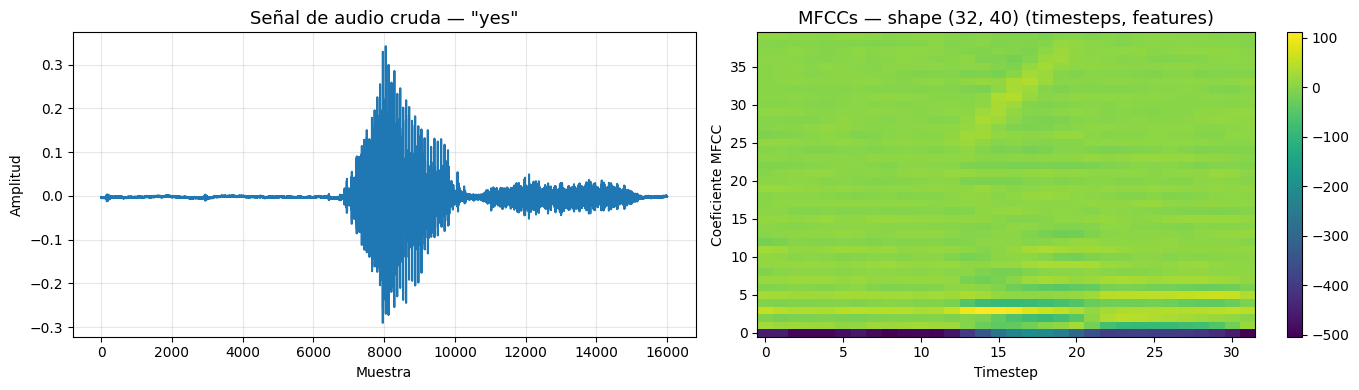


 Shape de un MFCC: (32, 40)  →  (timesteps, features) = input de la LSTM


In [ ]:
#Normaliza los auidos
def load_audio(file_path, sr=SAMPLE_RATE, duration=DURATION):
    """Carga un .wav y lo normaliza a duración fija."""
    audio, _ = librosa.load(file_path, sr=sr, duration=duration)
    target_length = int(sr * duration)
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]
    return audio


def extract_mfcc(audio, sr=SAMPLE_RATE, n_mfcc=N_MFCC):
    """
    Extrae MFCCs del audio.
    Output shape: (n_frames, n_mfcc)   formato (timesteps, features) para LSTM
    """
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=n_mfcc,
        hop_length=HOP_LENGTH, n_fft=N_FFT
    )
    return mfcc.T   # (n_mfcc, frames) → (frames, n_mfcc)


def build_dataset(data_dir, commands=COMMANDS):
    """Carga todos los audios y extrae sus MFCCs."""
    X, y = [], []

    for command in commands:
        cmd_dir = os.path.join(data_dir, command)
        if not os.path.exists(cmd_dir):
            print(f'  Directorio no encontrado: {cmd_dir}')
            continue

        files = [f for f in os.listdir(cmd_dir) if f.endswith('.wav')]
        print(f"\nProcesando '{command}' ({len(files)} archivos)")

        for filename in tqdm(files, desc=command):
            try:
                audio = load_audio(os.path.join(cmd_dir, filename))
                X.append(extract_mfcc(audio))
                y.append(command)
            except Exception as e:
                print(f'   Error en {filename}: {e}')

    return np.array(X), np.array(y)


# --- Visualización de ejemplo para entender los MFCCs ---
example_file = os.path.join(data_dir, 'yes',
                os.listdir(os.path.join(data_dir, 'yes'))[0])
example_audio = load_audio(example_file)
example_mfcc  = extract_mfcc(example_audio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(example_audio)
axes[0].set_title('Señal de audio cruda — "yes"', fontsize=13)
axes[0].set_xlabel('Muestra'); axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

img = axes[1].imshow(example_mfcc.T, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f'MFCCs — shape {example_mfcc.shape} (timesteps, features)', fontsize=13)
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Coeficiente MFCC')
plt.colorbar(img, ax=axes[1])
plt.tight_layout()
plt.show()
print(f'\n Shape de un MFCC: {example_mfcc.shape}  →  (timesteps, features) = input de la LSTM')

 Archivo: Clases/Clase6/speech_commands_data\mini_speech_commands\yes\0135f3f2_nohash_0.wav
  Duración : 1.00 s
  Sample rate: 16000 Hz

 Reproductor:


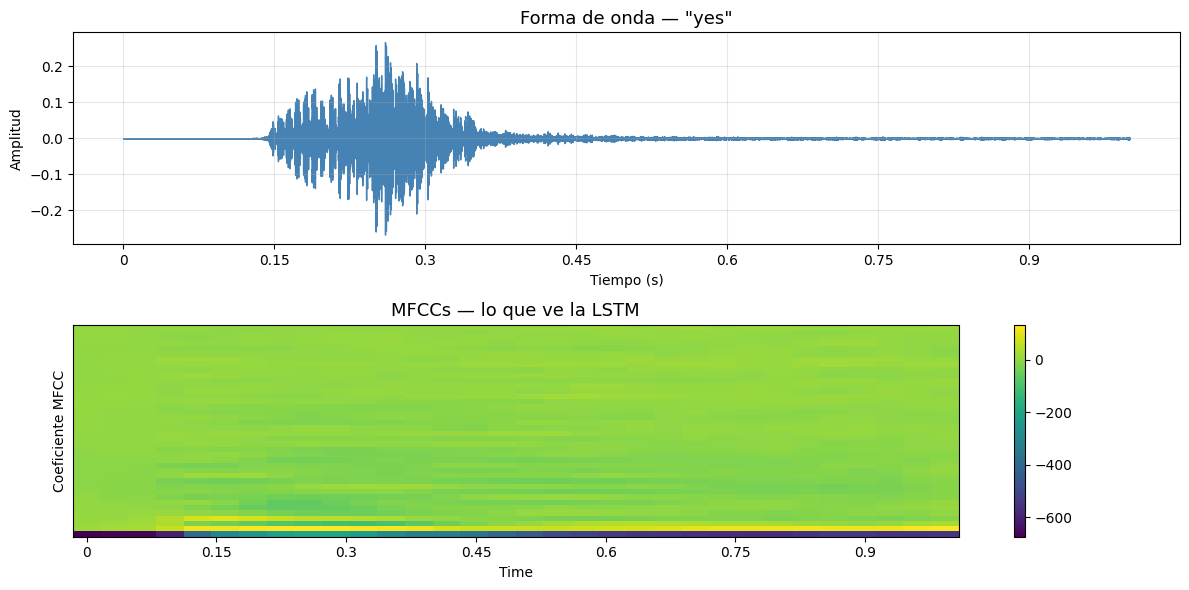

In [5]:
#Escuchamos el audio
# Tomamos el primer archivo .wav de la carpeta 'yes'
yes_dir  = os.path.join(data_dir, 'yes')
wav_file = os.path.join(yes_dir, os.listdir(yes_dir)[5])
print(f' Archivo: {wav_file}')

# --- Cargar el audio ---
audio, sr = librosa.load(wav_file, sr=16000)
print(f'  Duración : {len(audio)/sr:.2f} s')
print(f'  Sample rate: {sr} Hz')

# --- Reproducir directamente en Colab ---
print('\n Reproductor:')
display(Audio(audio, rate=sr))

# --- Visualizar señal + MFCCs ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Forma de onda
librosa.display.waveshow(audio, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_title('Forma de onda — "yes"', fontsize=13)
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

# MFCCs
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
img  = librosa.display.specshow(mfcc, sr=sr, x_axis='time', ax=axes[1], cmap='viridis')
axes[1].set_title('MFCCs — lo que ve la LSTM', fontsize=13)
axes[1].set_ylabel('Coeficiente MFCC')
fig.colorbar(img, ax=axes[1])

plt.tight_layout()
plt.show()

 Extrayendo MFCCs de todos los audios


Procesando 'yes' (1000 archivos)


yes:   0%|          | 0/1000 [00:00<?, ?it/s]


Procesando 'no' (1000 archivos)


no:   0%|          | 0/1000 [00:00<?, ?it/s]


Procesando 'up' (1000 archivos)


...


Procesando 'stop' (1000 archivos)


stop:   0%|          | 0/1000 [00:00<?, ?it/s]


Procesando 'go' (1000 archivos)


go:   0%|          | 0/1000 [00:00<?, ?it/s]


 Dataset construido
   X shape : (8000, 32, 40)  →  (muestras, timesteps, features)
   y shape : (8000,)


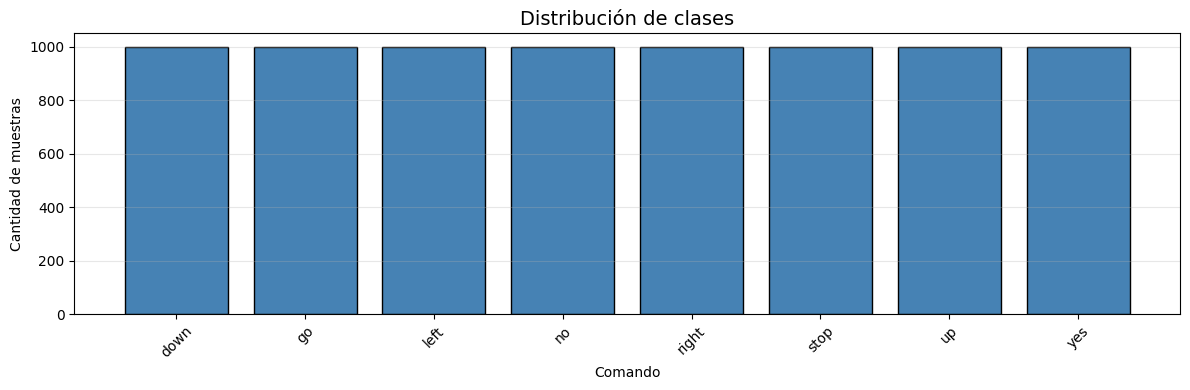

In [6]:
from tqdm.notebook import tqdm
print(' Extrayendo MFCCs de todos los audios\n')
X, y_labels = build_dataset(data_dir, commands=COMMANDS)

print(f'\n Dataset construido')
print(f'   X shape : {X.shape}  →  (muestras, timesteps, features)')
print(f'   y shape : {y_labels.shape}')

# Distribución de clases
unique, counts = np.unique(y_labels, return_counts=True)
plt.figure(figsize=(12, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.title('Distribución de clases', fontsize=14)
plt.xlabel('Comando'); plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# --- Codificar etiquetas ---
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
num_classes = len(label_encoder.classes_)
print(f'Clases ({num_classes}): {label_encoder.classes_}')

# --- Split 70 / 15 / 15 ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp
)
print(f'\nTrain : {X_train.shape[0]} muestras')
print(f'Val   : {X_val.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]} muestras')

# --- Normalización z-score (solo stats de train para evitar data leakage) ---
mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Guardamos stats para usarlas en inferencia
np.save('Clases/Clase6/norm_mean.npy', mean)
np.save('Clases/Clase6/norm_std.npy',  std)
print('\n Normalización aplicada y stats guardadas')

Clases (8): ['down' 'go' 'left' 'no' 'right' 'stop' 'up' 'yes']

Train : 5600 muestras
Val   : 1200 muestras
Test  : 1200 muestras

 Normalización aplicada y stats guardadas


In [ ]:
# Modelo LSTM con Batch Normalization
def build_lstm_model(input_shape, num_classes):
    """
    Arquitectura:
      Input
        → LSTM(128) → BatchNorm → Dropout
        → LSTM(64)  → BatchNorm → Dropout
        → Dense(64) → BatchNorm → Dropout
        → Softmax
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # ---  LSTM + BatchNorm + Dropout ---
        layers.LSTM(128, return_sequences=True, name='lstm_1'),
        layers.BatchNormalization(name='bn_1'),   # ← normaliza salida de lstm_1
        layers.Dropout(0.3, name='drop_1'),

        # ---  LSTM + BatchNorm + Dropout ---
        layers.LSTM(64, return_sequences=False, name='lstm_2'),
        layers.BatchNormalization(name='bn_2'),   # ← normaliza salida de lstm_2
        layers.Dropout(0.3, name='drop_2'),

        # ---  Dense + BatchNorm + Dropout ---
        layers.Dense(64, activation='relu', name='dense_1'),
        layers.BatchNormalization(name='bn_3'),   # ← normaliza antes del último Dropout
        layers.Dropout(0.2, name='drop_3'),

        # --- Salida ---
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='SpeechLSTM_BN')

    return model


input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm_model(input_shape, num_classes)
model.summary()
print(f'\n Modelo creado | Input shape: {input_shape} | Clases: {num_classes}')

Model: "SpeechLSTM_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32, 128)        │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,640 (553.28 KB)

 Trainable params: 141,128 (551.28 KB)

 Non-trainable params: 512 (2.00 KB)


 Modelo creado | Input shape: (32, 40) | Clases: 8


In [9]:
#Entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print(' Iniciando entrenamiento.')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

 Iniciando entrenamiento.
Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.1965 - loss: 2.3974
Epoch 1: val_accuracy improved from None to 0.30583, saving model to Clases/Clase6/speech_lstm_model.keras

Epoch 1: finished saving model to Clases/Clase6/speech_lstm_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - accuracy: 0.2391 - loss: 2.1844 - val_accuracy: 0.3058 - val_loss: 1.8150 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3555 - loss: 1.7244
Epoch 2: val_accuracy improved from 0.30583 to 0.45333, saving model to Clases/Clase6/speech_lstm_model.keras

Epoch 2: finished saving model to Clases/Clase6/speech_lstm_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.3786 - loss: 1.6709 - val_accuracy: 0.4533 - val_loss: 1.4655 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4489 - loss: 1.4296
Epoch 3: val_accuracy improved from 0.45333 to 0.55500, saving model to Cla

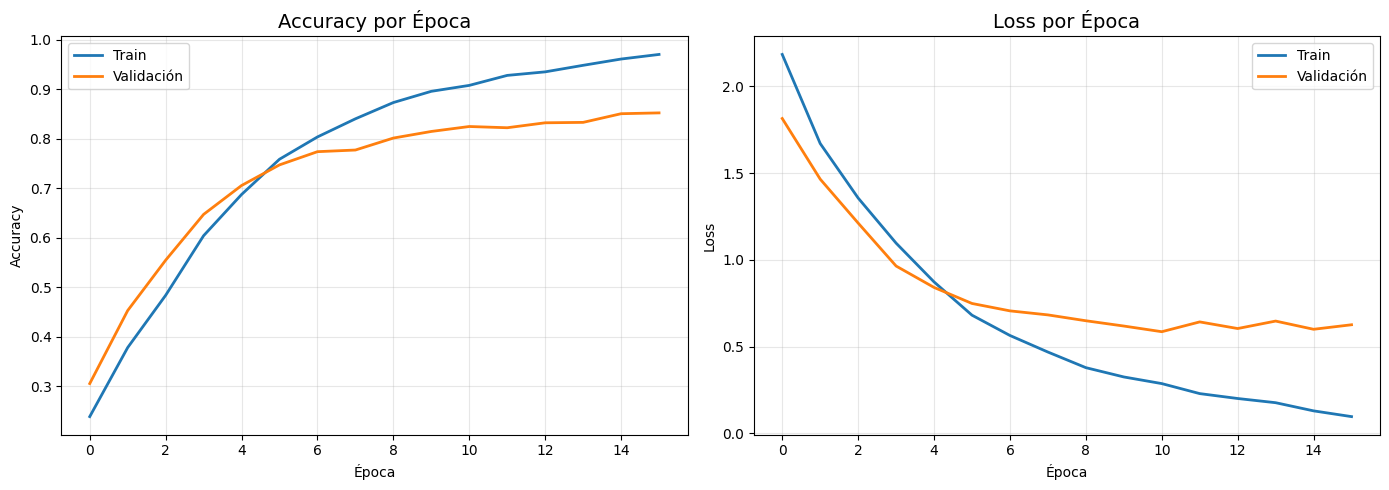

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train',     linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validación',linewidth=2)
axes[0].set_title('Accuracy por Época', fontsize=14)
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train',     linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validación', linewidth=2)
axes[1].set_title('Loss por Época', fontsize=14)
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  Test Accuracy : 0.8508 (85.08%)
  Test Loss     : 0.5834
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
              precision    recall  f1-score   support

        down       0.86      0.81      0.84       150
          go       0.80      0.81      0.80       150
        left       0.85      0.84      0.85       150
          no       0.78      0.77      0.77       150
       right       0.91      0.91      0.91       150
        stop       0.92      0.91      0.91       150
          up       0.81      0.86      0.83       150
         yes       0.89      0.91      0.90       150

    accuracy                           0.85      1200
   macro avg       0.85      0.85      0.85      1200
weighted avg       0.85      0.85      0.85      1200



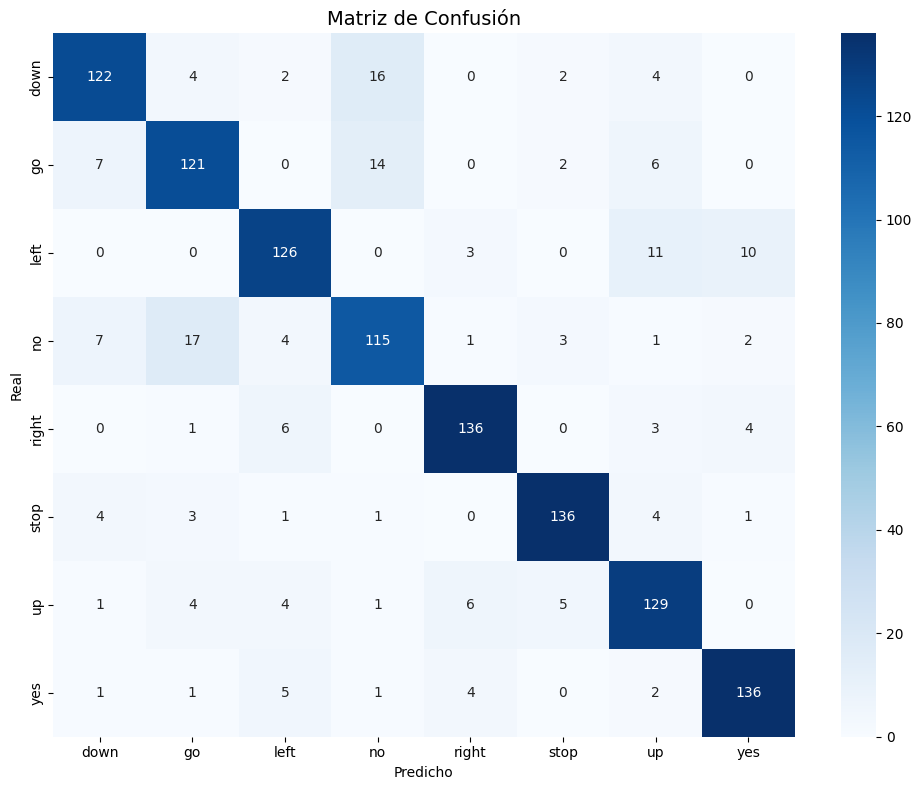

In [ ]:
# Cargar el mejor modelo guardado
best_model = keras.models.load_model(MODEL_PATH)

# Métricas generales
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'  Test Loss     : {test_loss:.4f}')

# Predicciones
y_pred = np.argmax(best_model.predict(X_test), axis=1)

# Classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión', fontsize=14)
plt.ylabel('Real'); plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import Audio, display  # reproducción de audio compatible para VS code

#Ruta del archivo de audio, importante cargarlo en wav
my_file = "Clases/Clase6/AudioMio.wav" 

# Ruta de los archivos guardados 
MODEL_PATH  = 'Clases/Clase6/speech_lstm_model.keras'  
NORM_MEAN_PATH = 'Clases/Clase6/norm_mean.npy'         
NORM_STD_PATH  = 'Clases/Clase6/norm_std.npy'

#Cargar audio
audio, sr = librosa.load(my_file, sr=SAMPLE_RATE, duration=DURATION)
target_length = int(SAMPLE_RATE * DURATION)
audio = np.pad(audio, (0, target_length - len(audio))) if len(audio) < target_length else audio[:target_length]

print(f' Archivo : {os.path.basename(my_file)}')
print(' Escuchar:')

#Reproduccion con Vs code
display(Audio(data=audio, rate=sr))

# Cargar el modelo entrenado
norm_mean = np.load(NORM_MEAN_PATH)  # shape (1, 1, 40)
norm_std  = np.load(NORM_STD_PATH)   # shape (1, 1, 40)

# Extraer MFCCs, normalizar y preparar para el modelo
mfcc = extract_mfcc(audio)                   # shape: (frames, 40)
mfcc = (mfcc - norm_mean.squeeze()) / norm_std.squeeze()  # broadcast seguro
mfcc = np.expand_dims(mfcc, axis=0)          # shape: (1, frames, 40) para el modelo

#Predicción
probs         = best_model.predict(mfcc, verbose=0)[0]
predicted_idx = np.argmax(probs)
label         = label_encoder.inverse_transform([predicted_idx])[0]
confidence    = probs[predicted_idx]

print(f'\n Comando detectado : "{label}"  (confianza: {confidence:.2%})')
print('\nTop 3 predicciones:')
for idx in np.argsort(probs)[::-1][:3]:
    lbl = label_encoder.inverse_transform([idx])[0]
    bar = '█' * int(probs[idx] * 20)
    print(f'   {lbl:8s}  {bar:20s}  {probs[idx]:.2%}')

 Archivo : AudioMio.wav
 Escucha tu audio:



 Comando detectado : "no"  (confianza: 96.33%)

Top 3 predicciones:
   no        ███████████████████   96.33%
   go                              2.51%
   down                            0.88%
